In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
cleaned_superstore_data = pd.read_csv('../data/cleaned_superstore_data.csv')
df = cleaned_superstore_data.copy()
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit', 'ship_time'],
      dtype='str')

## SECTION 1 — Date & Time Features

### We want to compare sales in 2015 vs 2016 vs 2017 vs 2018.

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_year'] = df['order_date'].dt.year
df['order_year'].head()

0    2016
1    2016
2    2016
3    2015
4    2015
Name: order_year, dtype: int32

In [7]:
df['order_month'] = df['order_date'].dt.month
df['order_month'].head()

df['order_month_name'] = df['order_date'].dt.month_name()
df['order_month_name'].head()

0    November
1    November
2        June
3     October
4     October
Name: order_month_name, dtype: str

In [8]:
# Order quarter
df['order_quarter'] = df['order_date'].dt.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})
df['order_quarter'].head()

0    Q4
1    Q4
2    Q2
3    Q4
4    Q4
Name: order_quarter, dtype: str

In [9]:
# Day of the week
df['order_day_name'] = df['order_date'].dt.day_name()
# Do customers order more on certain days of the week?
df['order_day_name'].value_counts()


order_day_name
Monday       1871
Friday       1818
Sunday       1710
Saturday     1655
Thursday     1463
Tuesday      1106
Wednesday     371
Name: count, dtype: int64

In [10]:
# weekend indicator: True for Saturday and Sunday
df['is_weekend'] = df['order_day_name'].isin(['Saturday', 'Sunday'])
df[['order_date', 'order_day_name', 'is_weekend']].head()


,order_date,order_day_name,is_weekend
0,2016-11-08,Tuesday,False
1,2016-11-08,Tuesday,False
2,2016-06-12,Sunday,True
3,2015-10-11,Sunday,True
4,2015-10-11,Sunday,True


## SECTION 2 — PROFIT MARGIN

### Create Profit Margin

In [11]:
# Check if we have any sales with zero value to avoid division by zero errors
zero_sales = df[df['sales'] == 0]
print(f"Number of sales with zero value: {len(zero_sales)}")


Number of sales with zero value: 0


### There are no sales with the value of 0. Calculate Profit Margin

In [12]:
df['profit_margin'] = (df['profit'] / df['sales']) * 100
df[['profit', 'sales', 'profit_margin']].head()
# if there were any zero sales, we would need to handle them before calculating profit margin to avoid division by zero errors.
# df['profit_margin'] = df.apply(lambda row: (row['profit'] / row['sales']) * 100 if row['sales'] != 0 else 0, axis=1)

,profit,sales,profit_margin
0,41.9136,261.9600,16.00
1,219.5820,731.9400,30.00
2,6.8714,14.6200,47.00
3,-383.0310,957.5775,-40.00
4,2.5164,22.3680,11.25


In [13]:
#investigate profit margin.
df['profit_margin'].describe()
#Which product has the highest profit margin?
highest_profit_margin_product = df.loc[df['profit_margin'].idxmax()]
print(f"Product with the highest profit margin:\n{highest_profit_margin_product[['product_name', 'profit_margin']]}")
# Which product has the lowest profit margin? 
lowest_profit_margin_product = df.loc[df['profit_margin'].idxmin()]
print(f"Product with the lowest profit margin:\n{lowest_profit_margin_product[['product_name', 'profit_margin']]}")


Product with the highest profit margin:
product_name     Prang Dustless Chalk Sticks
profit_margin                           50.0
Name: 61, dtype: object
Product with the lowest profit margin:
product_name     Eureka Disposable Bags for Sanitaire Vibra Gro...
profit_margin                                               -275.0
Name: 261, dtype: object


##### Which transactions have the highest margins? The transaction with the highest profit margin is for Prang Dustless Chalk Stick, with a margin of 50%.
##### Which has the lowest margins? The transaction with the lowest profit margin is for Eureka Disposable Bags for Sanitaire, with a margin of -275%.
##### Are there negative margins? Yes there are negative margins. 

### Create margin category 

In [14]:
# create margin category
conditions = [
	df['profit_margin'] < 0,
	(df['profit_margin'] >= 0) & (df['profit_margin'] < 10),
	(df['profit_margin'] >= 10) & (df['profit_margin'] < 30),
	df['profit_margin'] >= 30,
]
choices = ['Loss', 'Low', 'Medium', 'High']
df['margin_category'] = np.select(conditions, choices, default='Unknown')

# show counts and a sample
print(df['margin_category'].value_counts(dropna=False))
df[['profit', 'sales', 'profit_margin', 'margin_category']].head()


margin_category
High      4302
Medium    2758
Loss      1871
Low       1063
Name: count, dtype: int64


,profit,sales,profit_margin,margin_category
0,41.9136,261.9600,16.00,Medium
1,219.5820,731.9400,30.00,High
2,6.8714,14.6200,47.00,High
3,-383.0310,957.5775,-40.00,Loss
4,2.5164,22.3680,11.25,Medium


##### Transactions were grouped into four margin categories to make profitability easier to interpret. Negative margins are classified as Loss, while positive margins are divided into Low, Medium, and High profitability.

## SECTION 3 — ORDER-LEVEL METRICS

### Calculate total order sale

In [15]:
#Groupby order and sales
total_order_sales = df.groupby('order_id')['sales'].sum()
total_order_sales.head()

order_id
CA-2014-100006    377.970
CA-2014-100090    699.192
CA-2014-100293     91.056
CA-2014-100328      3.928
CA-2014-100363     21.376
Name: sales, dtype: float64

### Calculate total order profit

In [16]:
#Groupby order and profit
total_order_profit = df.groupby('order_id')['profit'].sum()
total_order_profit.head()

order_id
CA-2014-100006    109.6113
CA-2014-100090    -19.0890
CA-2014-100293     31.8696
CA-2014-100328      1.3257
CA-2014-100363      7.7192
Name: profit, dtype: float64

### Calculate number of product per order

In [17]:
#Groupby orderID and product id 
product_per_order = df.groupby('order_id')['product_id'].nunique()
product_per_order.head()

order_id
CA-2014-100006    1
CA-2014-100090    2
CA-2014-100293    1
CA-2014-100328    1
CA-2014-100363    2
Name: product_id, dtype: int64

### Calculate order quantity

In [18]:
#Groupby orderID and quantity 
quantity_of_order = df.groupby('order_id')['quantity'].sum()
quantity_of_order.head()

order_id
CA-2014-100006    3
CA-2014-100090    9
CA-2014-100293    6
CA-2014-100328    1
CA-2014-100363    5
Name: quantity, dtype: int64

### Calculate Order Profit Margin

In [19]:
#Groupby total_order_profit and total_order_sales
order_profit_margin = total_order_profit / total_order_sales * 100
order_profit_margin.head()

order_id
CA-2014-100006    29.000000
CA-2014-100090    -2.730151
CA-2014-100293    35.000000
CA-2014-100328    33.750000
CA-2014-100363    36.111527
dtype: float64

## SECTION 4 — CUSTOMER-LEVEL METRICS

### Costumer total sales

In [20]:
#Groupby costumer and sales
total_sales_for_each_customer = df.groupby('customer_name')['sales'].sum()
total_sales_for_each_customer.head()

customer_name
Aaron Bergman       886.156
Aaron Hawkins      1744.700
Aaron Smayling     3050.692
Adam Bellavance    7755.620
Adam Hart          3250.337
Name: sales, dtype: float64

### Costumer total Profit

In [21]:
#Groupby costumer and profit
total_profit_for_each_customer = df.groupby('customer_name')['profit'].sum()
total_profit_for_each_customer.head()

customer_name
Aaron Bergman       129.3465
Aaron Hawkins       365.2152
Aaron Smayling     -253.5746
Adam Bellavance    2054.5885
Adam Hart           281.1890
Name: profit, dtype: float64

### Customer number of orders

In [22]:
#Groupby costummer with orders id 
total_order_for_each_customer = df.groupby('customer_name')['order_id'].nunique()
total_order_for_each_customer.head()

customer_name
Aaron Bergman       3
Aaron Hawkins       7
Aaron Smayling      7
Adam Bellavance     8
Adam Hart          10
Name: order_id, dtype: int64

### Customer average order value

In [23]:
customer_average_order_value = total_sales_for_each_customer / total_order_for_each_customer
customer_average_order_value.head()

customer_name
Aaron Bergman      295.385333
Aaron Hawkins      249.242857
Aaron Smayling     435.813143
Adam Bellavance    969.452500
Adam Hart          325.033700
dtype: float64

### Customer profit margin

In [24]:
customer_profit_margin = total_profit_for_each_customer / total_sales_for_each_customer *100
customer_profit_margin.head()

customer_name
Aaron Bergman      14.596358
Aaron Hawkins      20.932837
Aaron Smayling     -8.312035
Adam Bellavance    26.491609
Adam Hart           8.651072
dtype: float64

## SECTION 5 — PRODUCT-LEVEL METRICS

### Product Total Sales

In [25]:
#Groupby product name and sales 
product_total_sales = df.groupby('product_name')['sales'].sum()
product_total_sales.head()

product_name
"While you Were Out" Message Book, One Form per Page     25.228
#10 Gummed Flap White Envelopes, 100/Box                 41.300
#10 Self-Seal White Envelopes                           108.682
#10 White Business Envelopes,4 1/8 x 9 1/2              488.904
#10- 4 1/8" x 9 1/2" Recycled Envelopes                 286.672
Name: sales, dtype: float64

### Product Total Profit

In [26]:
#Groupby product name and profit 
product_total_profit = df.groupby('product_name')['profit'].sum()
product_total_profit.head()

product_name
"While you Were Out" Message Book, One Form per Page     10.3880
#10 Gummed Flap White Envelopes, 100/Box                 16.7678
#10 Self-Seal White Envelopes                            52.1230
#10 White Business Envelopes,4 1/8 x 9 1/2              223.1408
#10- 4 1/8" x 9 1/2" Recycled Envelopes                 115.2806
Name: profit, dtype: float64

### Product Quantity Sold

In [27]:
#Groupby product name and quantity 
product_total_quantity = df.groupby('product_name')['quantity'].sum()
product_total_quantity.head()

product_name
"While you Were Out" Message Book, One Form per Page     8
#10 Gummed Flap White Envelopes, 100/Box                11
#10 Self-Seal White Envelopes                           10
#10 White Business Envelopes,4 1/8 x 9 1/2              32
#10- 4 1/8" x 9 1/2" Recycled Envelopes                 37
Name: quantity, dtype: int64

### Product Profit Margin

In [28]:
product_profit_margin = product_total_profit / product_total_sales * 100
product_profit_margin.head()

product_name
"While you Were Out" Message Book, One Form per Page    41.176471
#10 Gummed Flap White Envelopes, 100/Box                40.600000
#10 Self-Seal White Envelopes                           47.959184
#10 White Business Envelopes,4 1/8 x 9 1/2              45.641026
#10- 4 1/8" x 9 1/2" Recycled Envelopes                 40.213415
dtype: float64

In [66]:
# Identify product-level segments by sales and margin
product_segments = pd.DataFrame({
    'total_sales': product_total_sales,
    'total_profit': product_total_profit,
    'profit_margin': product_profit_margin,
})

sales_median = product_segments['total_sales'].median()
product_segments['sales_level'] = np.where(
    product_segments['total_sales'] >= sales_median,
    'High Sales',
    'Low Sales'
)
product_segments['margin_level'] = np.where(
    product_segments['profit_margin'] < 0,
    'Negative Margin',
    np.where(product_segments['profit_margin'] >= 30, 'High Margin', 'Low Margin')
)

conditions = [
    (product_segments['sales_level'] == 'High Sales') & (product_segments['margin_level'] == 'High Margin'),
    (product_segments['sales_level'] == 'High Sales') & (product_segments['margin_level'] == 'Low Margin'),
    (product_segments['sales_level'] == 'Low Sales') & (product_segments['margin_level'] == 'High Margin'),
    (product_segments['sales_level'] == 'Low Sales') & (product_segments['margin_level'] == 'Negative Margin'),
]
choices = [
    'High Sales + High Margin',
    'High Sales + Low Margin',
    'Low Sales + High Margin',
    'Low Sales + Negative Margin',
]
product_segments['sales_margin_segment'] = np.select(conditions, choices, default='Other')

print(product_segments['sales_margin_segment'].value_counts())
product_segments.reset_index().rename(columns={'index': 'product_name'}).head(12)

sales_margin_segment
Other                          554
High Sales + Low Margin        529
Low Sales + High Margin        466
High Sales + High Margin       198
Low Sales + Negative Margin    103
Name: count, dtype: int64


,product_name,total_sales,total_profit,profit_margin,sales_level,margin_level,sales_margin_segment
0,"""While you Were Out"" Message Book, One Form pe...",25.228,10.3880,41.176471,Low Sales,High Margin,Low Sales + High Margin
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,16.7678,40.600000,Low Sales,High Margin,Low Sales + High Margin
2,#10 Self-Seal White Envelopes,108.682,52.1230,47.959184,Low Sales,High Margin,Low Sales + High Margin
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",488.904,223.1408,45.641026,High Sales,High Margin,High Sales + High Margin
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,115.2806,40.213415,Low Sales,High Margin,Low Sales + High Margin
5,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",146.688,64.8636,44.218750,Low Sales,High Margin,Low Sales + High Margin
6,"#10-4 1/8"" x 9 1/2"" Premium Diagonal Seam Enve...",176.288,63.7470,36.160714,Low Sales,High Margin,Low Sales + High Margin
7,#6 3/4 Gummed Flap White Envelopes,71.280,24.9480,35.000000,Low Sales,High Margin,Low Sales + High Margin
8,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",2706.080,578.6848,21.384615,High Sales,Low Margin,High Sales + Low Margin
9,1/4 Fold Party Design Invitations & White Enve...,49.980,22.7115,45.441176,Low Sales,High Margin,Low Sales + High Margin


## SECTION 6 — DISCOUNT FEATURES

### Create Discount Category

In [30]:
# create discount category
conditions = [
	df['discount'] == 0,
	(df['discount'] > 0) & (df['discount'] < 0.3),
	(df['discount'] >= 0.3) & (df['discount'] < 0.6),
	df['discount'] >= 0.6,
]
choices = ['No Discount', 'Low Discount', 'Medium Discount', 'High Discount']
df['discount_category'] = np.select(conditions, choices, default='Unknown')

# preserve the desired order in plots and analysis
category_order = ['No Discount', 'Low Discount', 'Medium Discount', 'High Discount']
df['discount_category'] = pd.Categorical(df['discount_category'], categories=category_order, ordered=True)

df[['product_name', 'discount', 'discount_category']].head()

# show counts and a sampleprint(df['discount_category'].value_counts(dropna=False))

,product_name,discount,discount_category
0,Bush Somerset Collection Bookcase,0.00,No Discount
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",0.00,No Discount
2,Self-Adhesive Address Labels for Typewriters b...,0.00,No Discount
3,Bretford CR4500 Series Slim Rectangular Table,0.45,Medium Discount
4,Eldon Fold 'N Roll Cart System,0.20,Low Discount


### Discount Impact

In [31]:
discount_impact = df.groupby('discount_category')[['sales', 'profit', 'profit_margin']].agg('mean')
discount_impact.head()

,sales,profit,profit_margin
discount_category,,,
No Discount,226.742074,66.900292,34.016048
Low Discount,222.593279,26.501571,17.436785
Medium Discount,555.943039,-109.528873,-21.972719
High Discount,75.033572,-89.438144,-113.878505


##### Does average profit decrease as discount increases? Average profit decrease.
##### Does average profit margin decrease as discount increases? Average profit margin decrease 

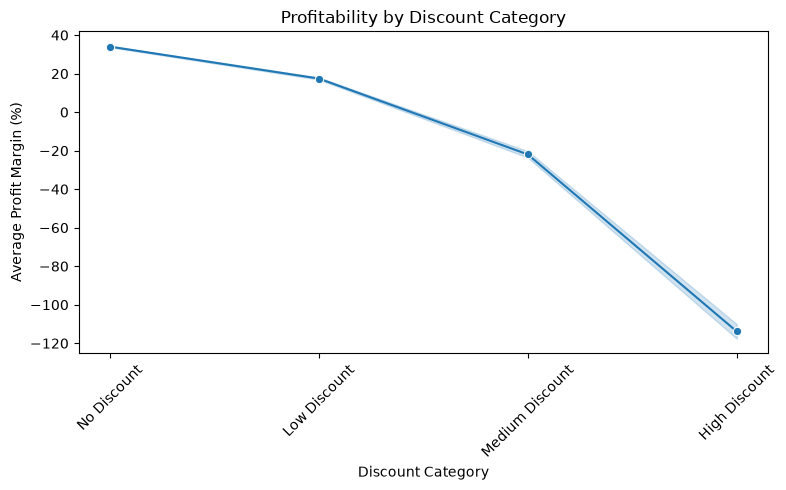

In [32]:
plt.figure(figsize=(8, 5))
category_order = ['No Discount', 'Low Discount', 'Medium Discount', 'High Discount']
sns.lineplot(data=df, x='discount_category', y='profit_margin', marker='o')
plt.title('Profitability by Discount Category')
plt.ylabel('Average Profit Margin (%)')
plt.xlabel('Discount Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### How does profitability efficiency change with discount? Higher discount categories are associated with lower average profit margins. This suggests that larger discounts may reduce profitability, although this analysis shows an association rather than proving causation.

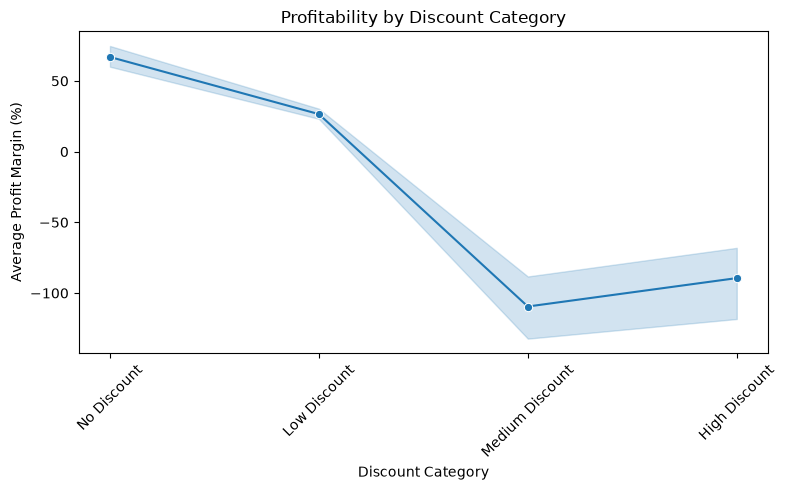

In [33]:
plt.figure(figsize=(8, 5))
category_order = ['No Discount', 'Low Discount', 'Medium Discount', 'High Discount']
sns.lineplot(data=df, x='discount_category', y='profit', marker='o')
plt.title('Profitability by Discount Category')
plt.ylabel('Average Profit Margin (%)')
plt.xlabel('Discount Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

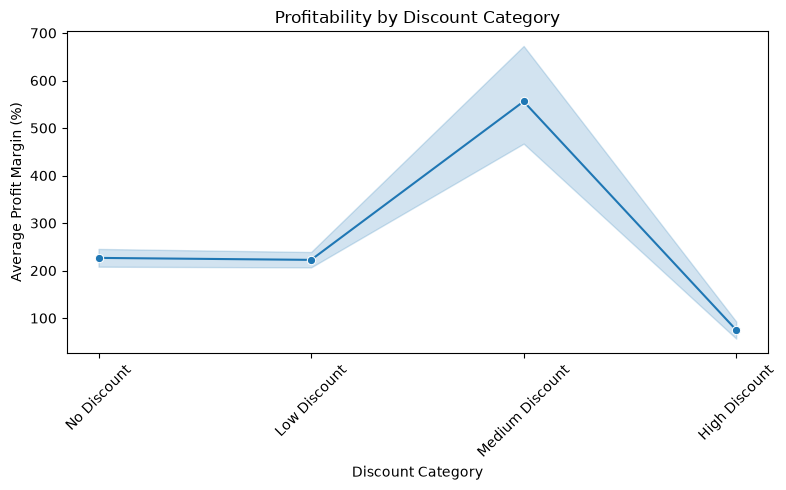

In [34]:
plt.figure(figsize=(8, 5))
category_order = ['No Discount', 'Low Discount', 'Medium Discount', 'High Discount']
sns.lineplot(data=df, x='discount_category', y='sales', marker='o')
plt.title('Profitability by Discount Category')
plt.ylabel('Average Profit Margin (%)')
plt.xlabel('Discount Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Do higher discounts correspond to higher sales? Although higher discounts are associated with increased average sales, the corresponding decline in profit margin suggests that additional revenue may come at the expense of profitability.

## SECTION 7 — SHIPPING FEATURES

### Shipping Category

In [35]:
df['ship_time'].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: ship_time, dtype: float64

In [59]:
# create ship_time category
conditions = [
	df['ship_time'] < 2,
	(df['ship_time'] >= 2) & (df['ship_time'] <= 5),
	df['ship_time'] > 5,
]
choices = ['Fast', 'Standard', 'Slow']
df['ship_time_category'] = np.select(conditions, choices, default='Unknown')

# preserve the desired order in plots and analysis
category_order = ['Fast', 'Standard', 'Slow']
df['ship_time_category'] = pd.Categorical(df['ship_time_category'], categories=category_order, ordered=True)

df[['product_name', 'ship_time', 'ship_time_category']].head()

,product_name,ship_time,ship_time_category
0,Bush Somerset Collection Bookcase,3,Standard
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",3,Standard
2,Self-Adhesive Address Labels for Typewriters b...,4,Standard
3,Bretford CR4500 Series Slim Rectangular Table,7,Slow
4,Eldon Fold 'N Roll Cart System,7,Slow


### Shipping Performance

In [38]:
shipping_performance = (
    df.groupby('ship_time_category')
      .agg(
          average_profit=('profit', 'mean'),
          average_sales=('sales', 'mean'),
          average_profit_margin=('profit_margin', 'mean')
      )
      .round(2)
      .reset_index()
)

shipping_performance

,ship_time_category,average_profit,average_sales,average_profit_margin
0,Fast,25.82,217.21,13.33
1,Standard,28.82,233.36,11.75
2,Slow,29.39,222.03,12.53


##### Do slower shipments have different financial performance? No slower shipment do not have different financial performance as we can see form the table.

## SECTION 8 — BUSINESS CUSTOMER SEGMENTATION

### Customer Value Segment

In [44]:
customer_sales = (
    df.groupby('customer_id', as_index=False)
      .agg(
          total_sales=('sales', 'sum'),
          order_count=('order_id', 'nunique')
      )
)

low_cutoff = customer_sales['total_sales'].quantile(0.25)
high_cutoff = customer_sales['total_sales'].quantile(0.75)

customer_sales['value_segment'] = pd.cut(
    customer_sales['total_sales'],
    bins=[-float('inf'), low_cutoff, high_cutoff, float('inf')],
    labels=['Low value', 'Medium value', 'High value']
)

customer_sales.head()

,customer_id,total_sales,order_count,value_segment
0,AA-10315,5563.560,5,High value
1,AA-10375,1056.390,9,Low value
2,AA-10480,1790.512,4,Medium value
3,AA-10645,5086.935,6,High value
4,AB-10015,886.156,3,Low value


### Identify Problem Customers

In [58]:
# Find customers with high total sales but negative total profit
customer_performance = (
    df.groupby(['customer_id', 'customer_name'], as_index=False)
      .agg(
          total_sales=('sales', 'sum'),
          total_profit=('profit', 'sum'),
          order_count=('order_id', 'nunique')
      )
)

high_sales_threshold = customer_performance['total_sales'].quantile(0.75)

high_sales_negative_profit = customer_performance[
    (customer_performance['total_sales'] > high_sales_threshold) &
    (customer_performance['total_profit'] < 0)
].sort_values('total_sales', ascending=False)

print(f"There are {high_sales_negative_profit['customer_id'].count()} problematic customer")
high_sales_negative_profit

There are 26 problematic customer


,customer_id,customer_name,total_sales,total_profit,order_count
700,SM-20320,Sean Miller,25043.0500,-1980.7393,5
90,BM-11140,Becky Martin,11789.6300,-1659.9581,4
310,GT-14635,Grant Thornton,9351.2120,-4108.6589,3
588,PF-19120,Peter Fuller,9062.8640,-614.2943,4
560,NF-18385,Natalie Fritzler,8322.8260,-1695.9714,7
666,SB-20290,Sean Braxton,8057.8910,-2082.7451,7
791,ZC-21910,Zuschuss Carroll,8025.7070,-1032.1490,13
371,JH-15985,Joseph Holt,7954.9980,-644.6982,6
339,JA-15970,Joseph Airdo,6491.0260,-819.4217,8
786,VW-21775,Victoria Wilson,6134.0380,-874.6645,10


### Identify High-Potential Customers

In [ ]:
# Find customers with high profit margin and multiple orders

customer_high_potential = (
    df.groupby(['customer_id', 'customer_name'], as_index=False)
      .agg(
          total_sales=('sales', 'sum'),
          total_profit=('profit', 'sum'),
          order_count=('order_id', 'nunique')
      )
)

# Calculate the customer's overall profit margin
customer_high_potential['profit_margin'] = (
    customer_high_potential['total_profit']
    / customer_high_potential['total_sales']
) * 100

# Define "high" using the 75th percentile
high_profit_margin_threshold = (
    customer_high_potential['profit_margin'].quantile(0.75)
)

# Find customers with both high profit margin and many orders
high_profit_margin_multiple_orders = customer_high_potential[
    (customer_high_potential['profit_margin'] > high_profit_margin_threshold) &
    (customer_high_potential['order_count'] > 1)
].sort_values(
    'profit_margin',
    ascending=False
)

print(
    f"There are {len(high_profit_margin_multiple_orders)} "
    "high-potential customers"
)

high_profit_margin_multiple_orders

There are 194 high-potential customers


,customer_id,customer_name,total_sales,total_profit,order_count,profit_margin
741,TC-20980,Tamara Chand,19052.218,8981.3239,5,47.140569
621,RB-19360,Raymond Buch,15117.339,6976.0959,6,46.146322
712,SR-20740,Steven Roelle,4345.886,1990.4244,8,45.800198
97,BO-11425,Bobby Odegard,130.830,59.4522,2,45.442330
327,HL-15040,Hunter Lopez,12873.298,5622.4292,6,43.675127
...,...,...,...,...,...,...
461,LH-16900,Lena Hernandez,2295.332,526.0727,9,22.919242
332,HR-14830,Harold Ryan,5248.787,1196.9504,7,22.804324
561,NF-18475,Neil Französisch,377.162,85.9278,4,22.782730
274,EN-13780,Edward Nazzal,2199.366,496.1131,4,22.557096


### Save new df as csv


In [67]:
df.to_csv('../data/clean_data/cleaned_processed_superstore_data.csv', index=False)